STEP 1 — Import Libraries

In [1]:
# ===============================
# IMPORT LIBRARIES
# ===============================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Plot styling
plt.style.use('ggplot')

print("Libraries imported successfully.")

Libraries imported successfully.


STEP 2 — Load Dataset

In [2]:
# ===============================
# LOAD DATASET
# ===============================

file_path = "../data/TG-SPDCL_consumption_detail_non-domestic_and_commercial_04_2026.csv"

df = pd.read_csv(file_path)

print("Dataset Loaded Successfully.")

Dataset Loaded Successfully.


STEP 3 — Initial Inspection

In [3]:
# ===============================
# BASIC DATA INSPECTION
# ===============================

print("Shape of Dataset:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nFirst 5 Rows:")
display(df.head())

Shape of Dataset:
(15904, 11)

Column Names:
Index(['circle', 'division', 'subdivision', 'section', 'area', 'catdesc',
       'catcode', 'totservices', 'billdservices', 'units', 'load'],
      dtype='str')

First 5 Rows:


,circle,division,subdivision,section,area,catdesc,catcode,totservices,billdservices,units,load
0,BANJARA HILLS,GREEN LANDS,SANATH NAGAR,MOTHI NAGAR,MAHATMA NAGAR,NON-DOMESTIC AND COMMERCIAL,2,24,22.0,3334,30.44
1,BANJARA HILLS,GREEN LANDS,SANATH NAGAR,MOTHI NAGAR,N.R.R.PURAM -I (S),NON-DOMESTIC AND COMMERCIAL,2,77,76.0,9443,117.27
2,BANJARA HILLS,GREEN LANDS,SANATH NAGAR,MOTHI NAGAR,N.R.R.PURAM SITE - II,NON-DOMESTIC AND COMMERCIAL,2,24,23.0,3242,29.74
3,BANJARA HILLS,GREEN LANDS,SANATH NAGAR,MOTHI NAGAR,N.R.R.PURAM SITE - III,NON-DOMESTIC AND COMMERCIAL,2,105,101.0,16863,144.92
4,BANJARA HILLS,GREEN LANDS,SANATH NAGAR,MOTHI NAGAR,N.R.R.PURAM SITE -I,NON-DOMESTIC AND COMMERCIAL,2,101,99.0,6767,101.00


STEP 4 — Dataset Information

In [4]:
# ===============================
# DATASET INFORMATION
# ===============================

print("\nDataset Info:")
df.info()

print("\nStatistical Summary:")
display(df.describe())


Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 15904 entries, 0 to 15903
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   circle         15904 non-null  str    
 1   division       15904 non-null  str    
 2   subdivision    15904 non-null  str    
 3   section        15904 non-null  str    
 4   area           15860 non-null  str    
 5   catdesc        15904 non-null  str    
 6   catcode        15904 non-null  int64  
 7   totservices    15904 non-null  int64  
 8   billdservices  15657 non-null  float64
 9   units          15904 non-null  int64  
 10  load           15904 non-null  float64
dtypes: float64(2), int64(3), str(6)
memory usage: 2.6 MB

Statistical Summary:


,catcode,totservices,billdservices,units,load
count,15904.0,15904.000000,15657.000000,1.590400e+04,15904.000000
mean,2.0,86.500440,76.341636,2.312537e+04,305.453210
std,0.0,134.948205,117.558910,7.832224e+04,956.789102
min,2.0,1.000000,1.000000,-2.352000e+03,0.000000
25%,2.0,12.000000,11.000000,1.118750e+03,24.500000
50%,2.0,41.000000,37.000000,5.287000e+03,84.020000
75%,2.0,105.000000,94.000000,1.646500e+04,247.750000
max,2.0,3121.000000,2904.000000,1.884344e+06,24627.130000


STEP 5 — Check Missing Values

In [5]:
# ===============================
# CHECK MISSING VALUES
# ===============================

missing_values = df.isnull().sum()

missing_percentage = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Missing Percentage': missing_percentage
})

display(missing_df.sort_values(by='Missing Percentage', ascending=False))

,Missing Values,Missing Percentage
billdservices,247,1.553068
area,44,0.276660
circle,0,0.000000
subdivision,0,0.000000
division,0,0.000000
catdesc,0,0.000000
section,0,0.000000
catcode,0,0.000000
totservices,0,0.000000
units,0,0.000000


STEP 6 — Check Duplicate Records

In [6]:
# ===============================
# CHECK DUPLICATES
# ===============================

duplicates = df.duplicated().sum()

print(f"Total Duplicate Rows: {duplicates}")

Total Duplicate Rows: 0


STEP 7 — Clean Text Columns

In [7]:
# ===============================
# CLEAN TEXT COLUMNS
# ===============================

text_columns = [
    'circle',
    'division',
    'subdivision',
    'section',
    'area',
    'catdesc'
]

for col in text_columns:
    df[col] = df[col].astype(str).str.strip().str.upper()

print("Text columns standardized successfully.")

Text columns standardized successfully.


STEP 8 — Convert Numeric Columns

In [8]:
# ===============================
# CONVERT NUMERIC COLUMNS
# ===============================

numeric_columns = [
    'totservices',
    'billdservices',
    'units',
    'load'
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("Numeric conversion completed.")

Numeric conversion completed.


STEP 9 — Create Engineered Features

In [9]:
# ===============================
# FEATURE ENGINEERING
# ===============================

# Units Per Service
df['units_per_service'] = df['units'] / df['totservices']

# Service Utilization Ratio
df['service_utilization_ratio'] = (
    df['billdservices'] / df['totservices']
)

# Average Load Per Service
df['avg_load_per_service'] = (
    df['load'] / df['totservices']
)

# Load Efficiency
df['load_efficiency'] = (
    df['units'] / df['load']
)

print("Feature Engineering Completed.")

display(df.head())

Feature Engineering Completed.


,circle,division,subdivision,section,area,catdesc,catcode,totservices,billdservices,units,load,units_per_service,service_utilization_ratio,avg_load_per_service,load_efficiency
0,BANJARA HILLS,GREEN LANDS,SANATH NAGAR,MOTHI NAGAR,MAHATMA NAGAR,NON-DOMESTIC AND COMMERCIAL,2,24,22.0,3334,30.44,138.916667,0.916667,1.268333,109.526938
1,BANJARA HILLS,GREEN LANDS,SANATH NAGAR,MOTHI NAGAR,N.R.R.PURAM -I (S),NON-DOMESTIC AND COMMERCIAL,2,77,76.0,9443,117.27,122.636364,0.987013,1.522987,80.523578
2,BANJARA HILLS,GREEN LANDS,SANATH NAGAR,MOTHI NAGAR,N.R.R.PURAM SITE - II,NON-DOMESTIC AND COMMERCIAL,2,24,23.0,3242,29.74,135.083333,0.958333,1.239167,109.011432
3,BANJARA HILLS,GREEN LANDS,SANATH NAGAR,MOTHI NAGAR,N.R.R.PURAM SITE - III,NON-DOMESTIC AND COMMERCIAL,2,105,101.0,16863,144.92,160.600000,0.961905,1.380190,116.360751
4,BANJARA HILLS,GREEN LANDS,SANATH NAGAR,MOTHI NAGAR,N.R.R.PURAM SITE -I,NON-DOMESTIC AND COMMERCIAL,2,101,99.0,6767,101.00,67.000000,0.980198,1.000000,67.000000


STEP 10 — Handle Infinite Values

In [11]:
# ===============================
# HANDLE INFINITE & MISSING VALUES
# ===============================

# Replace infinite values with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Separate numeric and text columns
numeric_cols = df.select_dtypes(include=np.number).columns
text_cols = df.select_dtypes(include='object').columns

# Fill numeric missing values with 0
df[numeric_cols] = df[numeric_cols].fillna(0)

# Fill text missing values with 'UNKNOWN'
df[text_cols] = df[text_cols].fillna('UNKNOWN')

print("Infinite and missing values handled successfully.")

C:\Users\raghu\AppData\Local\Temp\ipykernel_4244\1854767092.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df.select_dtypes(include='object').columns


Infinite and missing values handled successfully.


STEP 11 — Top 10 Areas by Consumption

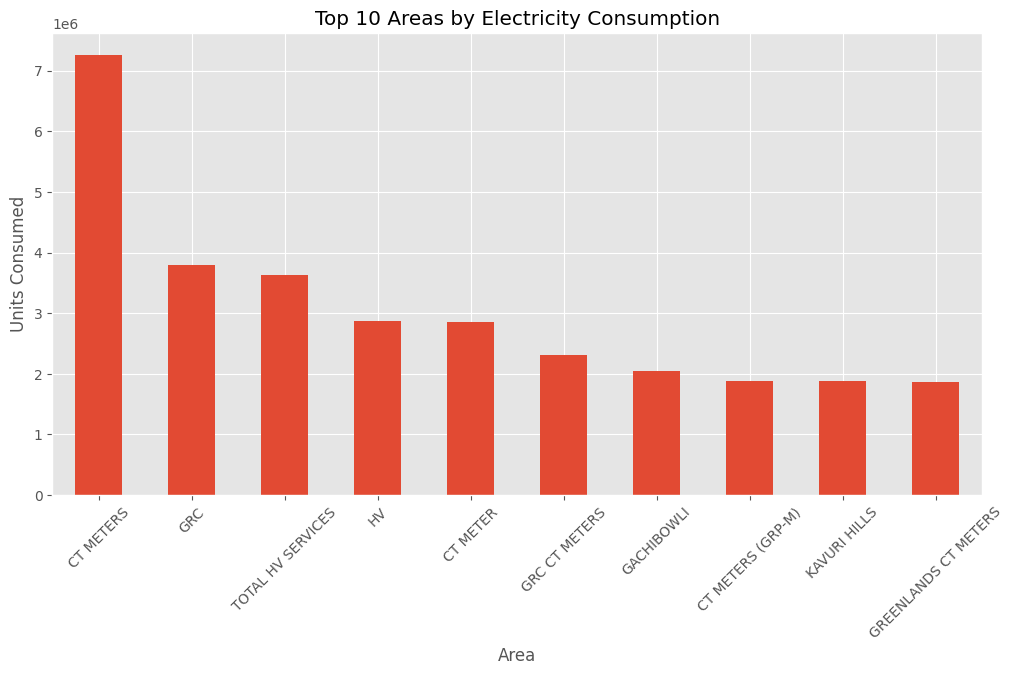

In [12]:
# ===============================
# TOP 10 AREAS BY UNITS CONSUMED
# ===============================

top_areas = (
    df.groupby('area')['units']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

top_areas.plot(kind='bar')

plt.title("Top 10 Areas by Electricity Consumption")
plt.xlabel("Area")
plt.ylabel("Units Consumed")

plt.xticks(rotation=45)

plt.show()

STEP 12 — Circle-wise Consumption Analysis

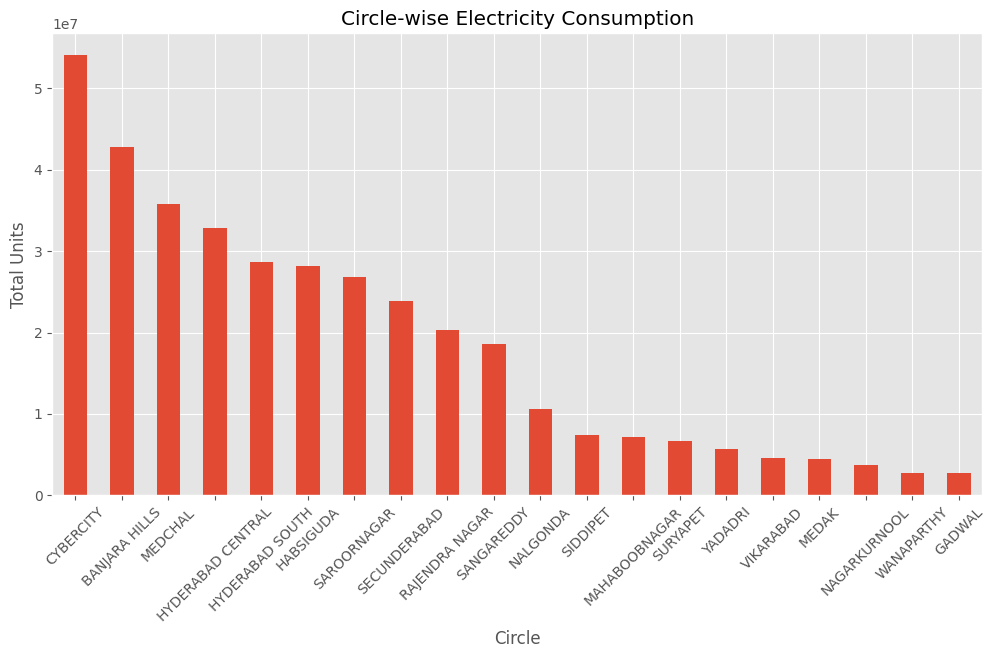

In [13]:
# ===============================
# CIRCLE-WISE CONSUMPTION
# ===============================

circle_consumption = (
    df.groupby('circle')['units']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

circle_consumption.plot(kind='bar')

plt.title("Circle-wise Electricity Consumption")
plt.xlabel("Circle")
plt.ylabel("Total Units")

plt.xticks(rotation=45)

plt.show()

STEP 13 — Units vs Load Scatter Plot

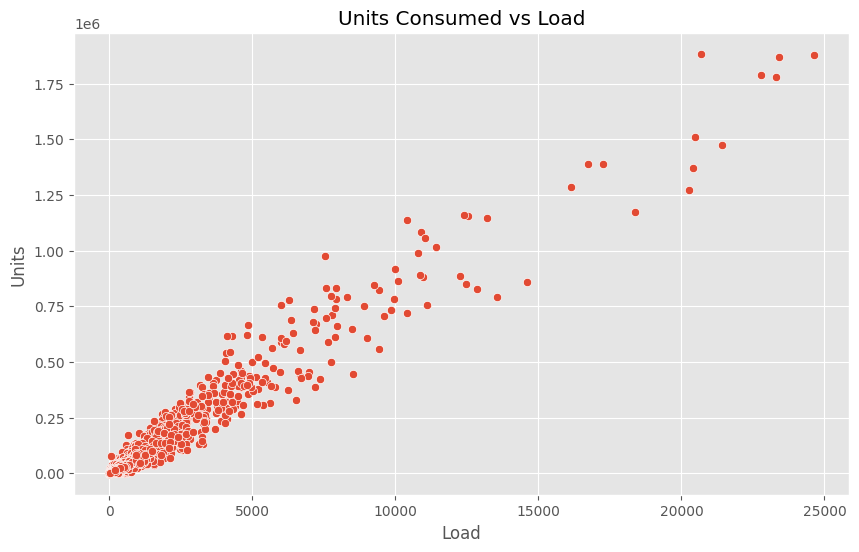

In [14]:
# ===============================
# UNITS VS LOAD
# ===============================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='load',
    y='units'
)

plt.title("Units Consumed vs Load")
plt.xlabel("Load")
plt.ylabel("Units")

plt.show()

STEP 14 — Correlation Heatmap

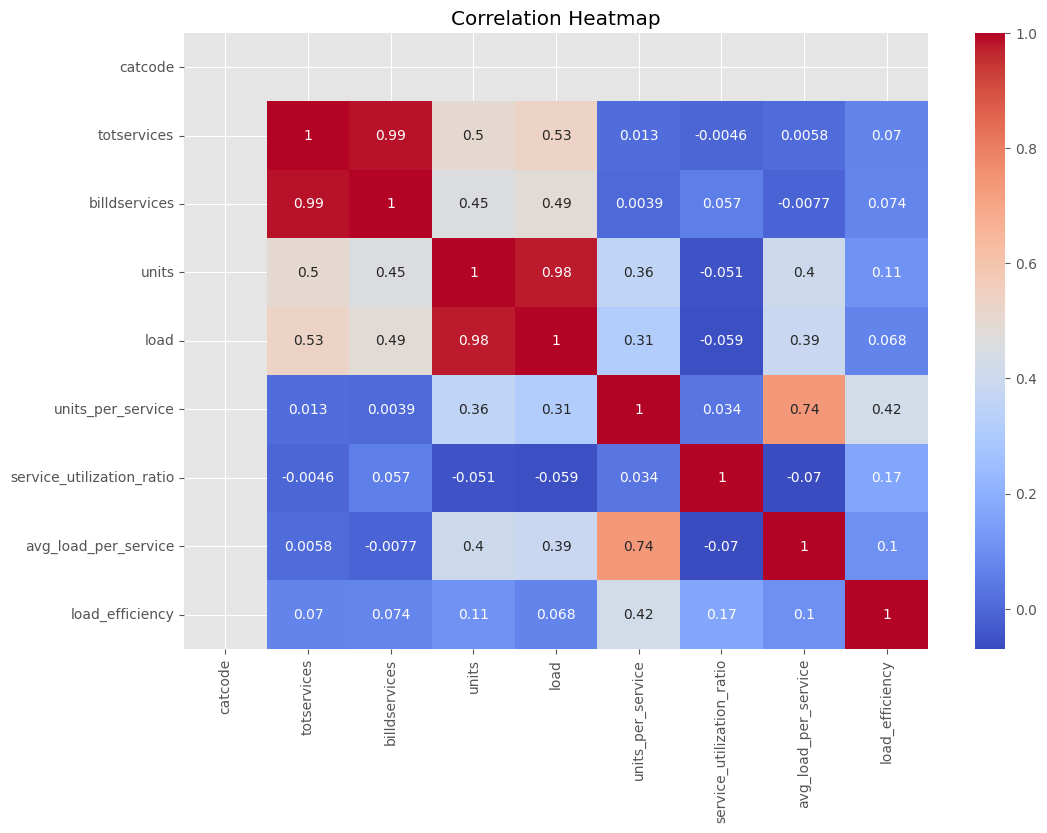

In [15]:
# ===============================
# CORRELATION HEATMAP
# ===============================

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

STEP 15 — Save Cleaned Dataset

In [16]:
# ===============================
# SAVE CLEANED DATASET
# ===============================

output_path = "../data/cleaned_tgspdcl_data.csv"

df.to_csv(output_path, index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.
